# Machine Learning Basics – Solved Notebook
**Brainhack School 2020 | Assignment 4**

Presenters: Estefany Suarez & Jacob Vogel  
Dataset: Iris (sklearn built-in)  
Library: scikit-learn

---


## 0. Imports & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings; warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print("All imports OK ✓")


All imports OK ✓


## 1. Load & Explore the Iris Dataset
The Iris dataset contains **150 samples** of iris flowers across **3 species** (setosa, versicolor, virginica).  
Each sample has **4 features**: sepal length, sepal width, petal length, petal width (all in cm).


In [ ]:
iris = datasets.load_iris()
X = iris.data    # shape (150, 4)
y = iris.target  # 0=setosa, 1=versicolor, 2=virginica

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Feature names        : {iris.feature_names}")
print(f"Target names         : {iris.target_names}")
print(f"\nFirst 5 samples:\n{X[:5]}")
print(f"\nClass distribution   : {np.bincount(y)}  (balanced – 50 each)")


Feature matrix shape : (150, 4)
Target vector shape  : (150,)
Feature names        : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names         : ['setosa' 'versicolor' 'virginica']

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Class distribution   : [50 50 50]  (balanced – 50 each)


## 2. Visualise the Data
Understanding your data before modelling is essential in machine learning.


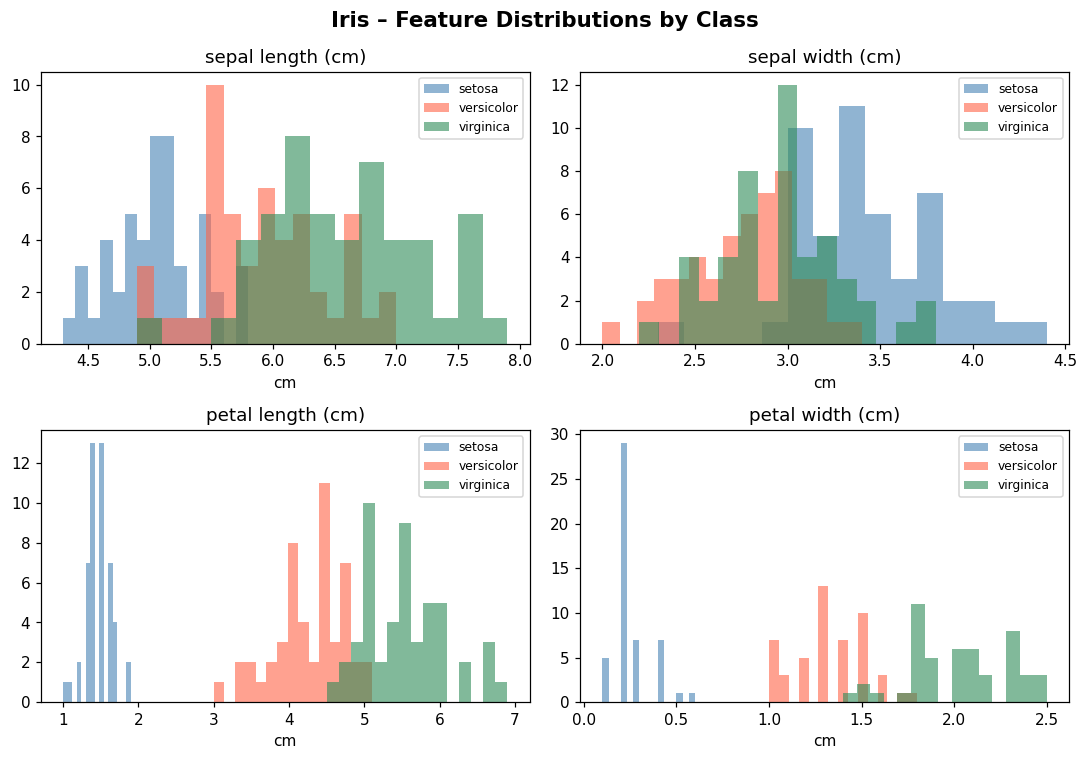

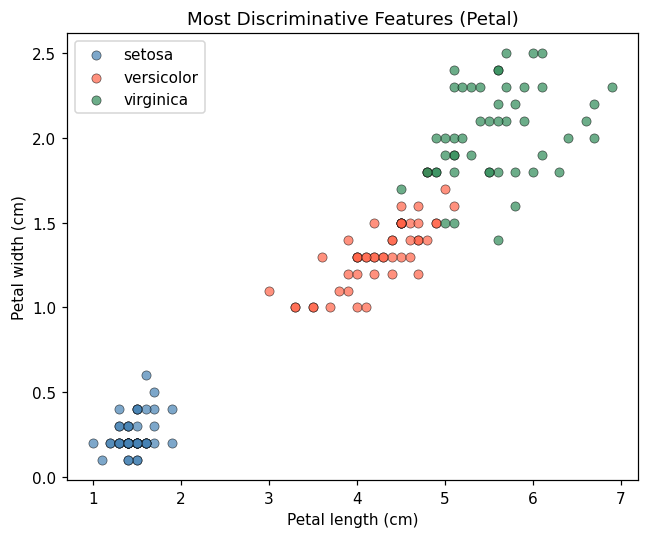

Observation: Setosa is perfectly linearly separable.
Versicolor & Virginica overlap slightly in petal width.


In [ ]:
colors = ['steelblue', 'tomato', 'seagreen']

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Iris – Feature Distributions by Class", fontsize=14, fontweight='bold')
for ax, feat_idx, feat_name in zip(axes.ravel(), range(4), iris.feature_names):
    for cls in range(3):
        ax.hist(X[y==cls, feat_idx], bins=15, alpha=0.6,
                color=colors[cls], label=iris.target_names[cls])
    ax.set_title(feat_name); ax.set_xlabel("cm"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Best 2-feature scatter (petal features are most discriminative)
fig, ax = plt.subplots(figsize=(6, 5))
for cls in range(3):
    ax.scatter(X[y==cls, 2], X[y==cls, 3], alpha=0.7,
               color=colors[cls], label=iris.target_names[cls],
               edgecolors='k', linewidths=0.4)
ax.set_xlabel("Petal length (cm)"); ax.set_ylabel("Petal width (cm)")
ax.set_title("Most Discriminative Features (Petal)"); ax.legend()
plt.tight_layout(); plt.show()

print("Observation: Setosa is perfectly linearly separable.")
print("Versicolor & Virginica overlap slightly in petal width.")


## 3. Train / Test Split & Feature Scaling
**Key rule:** fit the scaler ONLY on training data, then transform both sets.  
This prevents *data leakage* from the test set into the model.


In [ ]:
# 80 / 20 split, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train class dist: {np.bincount(y_train)}")
print(f"Test  class dist: {np.bincount(y_test)}")

# StandardScaler: (x - mean) / std
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_test_sc  = scaler.transform(X_test)        # transform only on test

print(f"\nAfter scaling – train mean: {X_train_sc.mean(axis=0).round(4)}  (≈ 0)")
print(f"After scaling – train std : {X_train_sc.std(axis=0).round(4)}   (≈ 1)")


Train: 120 samples | Test: 30 samples
Train class dist: [40 40 40]
Test  class dist: [10 10 10]

After scaling – train mean: [-0. -0.  0.  0.]  (≈ 0)
After scaling – train std : [1. 1. 1. 1.]   (≈ 1)


## 4. K-Nearest Neighbours (KNN) Classifier
KNN classifies a new point by majority vote among its **k nearest neighbours** in feature space.


KNN (k=5) Test Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



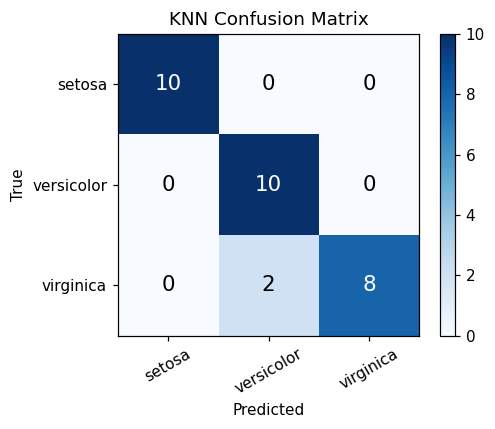

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

print(f"KNN (k=5) Test Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(iris.target_names, rotation=30)
ax.set_yticklabels(iris.target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("KNN Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j]>cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


Best k = 1  |  Accuracy = 0.9667


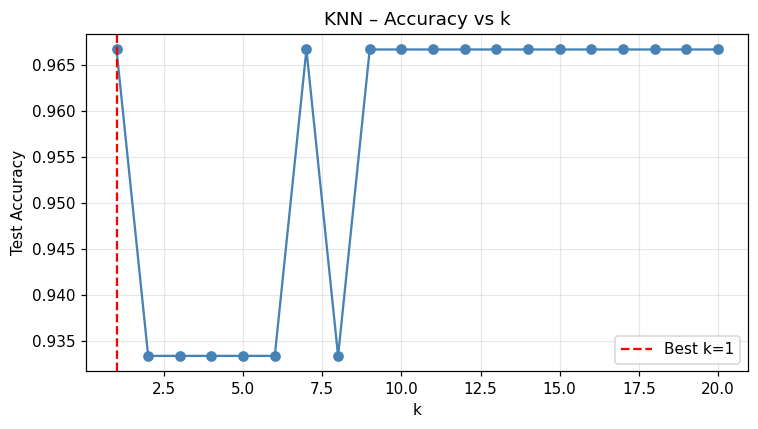

In [ ]:
# Choosing the best k
k_scores = []
k_range = range(1, 21)
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_sc, y_train)
    k_scores.append(accuracy_score(y_test, knn_k.predict(X_test_sc)))

best_k = list(k_range)[np.argmax(k_scores)]
print(f"Best k = {best_k}  |  Accuracy = {max(k_scores):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, k_scores, 'o-', color='steelblue')
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel("k"); ax.set_ylabel("Test Accuracy")
ax.set_title("KNN – Accuracy vs k"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Comparing Multiple Classifiers
Different algorithms make different assumptions. Let's compare several on the same data.


In [ ]:
classifiers = {
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':     SVC(kernel='rbf', C=1.0, random_state=42),
    'Logistic Reg.': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

print(f"{'Classifier':<20} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 42)
test_accs = {}
for name, clf in classifiers.items():
    clf.fit(X_train_sc, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train_sc))
    te = accuracy_score(y_test,  clf.predict(X_test_sc))
    test_accs[name] = te
    print(f"{name:<20} {tr:>10.4f} {te:>10.4f}")

print("\nNote: Decision Tree & Random Forest have 1.00 train accuracy → overfitting!")


Classifier            Train Acc   Test Acc
------------------------------------------
KNN (k=5)                0.9750     0.9333
SVM (RBF)                0.9750     0.9667
Logistic Reg.            0.9583     0.9333
Decision Tree            1.0000     0.9333
Random Forest            1.0000     0.9000

Note: Decision Tree & Random Forest have 1.00 train accuracy → overfitting!


## 6. Cross-Validation (5-Fold)
A single train/test split can give lucky or unlucky results.  
**Cross-validation** repeatedly splits the data and averages performance — more reliable.


Classifier              CV Mean     CV Std
------------------------------------------
KNN (k=5)                0.9600     0.0249
SVM (RBF)                0.9667     0.0211
Logistic Reg.            0.9600     0.0389
Decision Tree            0.9533     0.0340
Random Forest            0.9667     0.0211


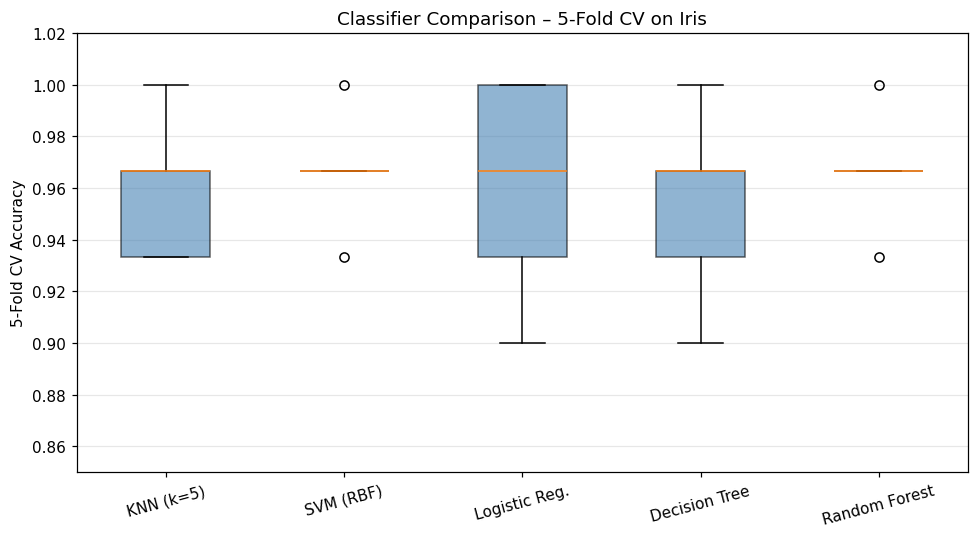

In [ ]:
cv_results = {}
print(f"{'Classifier':<20} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 42)
for name, clf in classifiers.items():
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', clf.__class__(**clf.get_params()))])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<20} {scores.mean():>10.4f} {scores.std():>10.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(cv_results.values(), tick_labels=cv_results.keys(),
           patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel("5-Fold CV Accuracy"); ax.set_ylim(0.85, 1.02)
ax.set_title("Classifier Comparison – 5-Fold CV on Iris")
ax.grid(axis='y', alpha=0.3); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


## 7. Learning Curve – Diagnosing Bias & Variance
A learning curve shows how performance changes as training set size grows.  
- **Gap between train & validation** → high variance (overfitting)  
- **Both curves low** → high bias (underfitting)


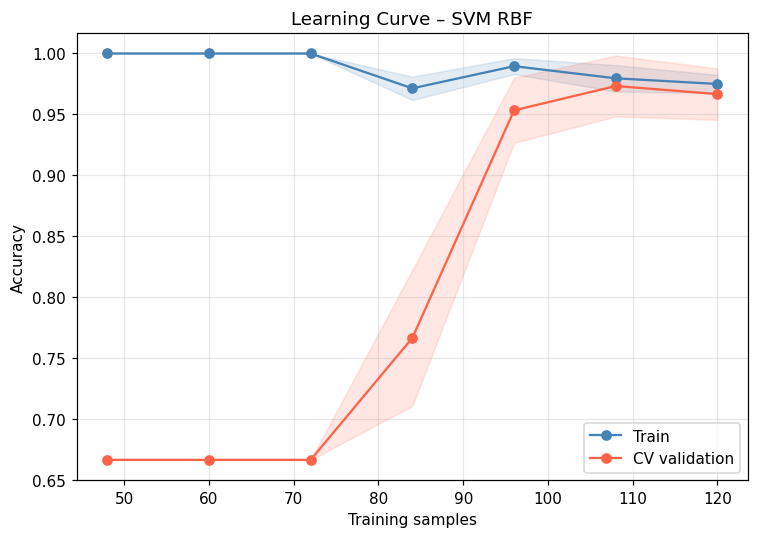

Interpretation: Train & CV curves converge at high sample counts → low variance, good generalisation.


In [ ]:
pipe_svm = Pipeline([('scaler', StandardScaler()),
                     ('svm', SVC(kernel='rbf', C=1.0, random_state=42))])
train_sizes, train_scores, val_scores = learning_curve(
    pipe_svm, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', random_state=42, error_score=np.nan
)

# Use only sizes where all folds have ≥2 classes (avoid SVM error on tiny splits)
ts, tr, vs = train_sizes, train_scores, val_scores

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts, tr.mean(1), 'o-', color='steelblue', label='Train')
ax.fill_between(ts, tr.mean(1)-tr.std(1), tr.mean(1)+tr.std(1), alpha=0.15, color='steelblue')
ax.plot(ts, vs.mean(1), 'o-', color='tomato', label='CV validation')
ax.fill_between(ts, vs.mean(1)-vs.std(1), vs.mean(1)+vs.std(1), alpha=0.15, color='tomato')
ax.set_xlabel("Training samples"); ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve – SVM RBF"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Interpretation: Train & CV curves converge at high sample counts → low variance, good generalisation.")


## 8. Dimensionality Reduction with PCA
PCA finds the directions of maximum variance. Projecting to 2D lets us **visualise** high-dimensional data.


Explained variance ratio : [0.7296 0.2285]
Total variance explained : 95.8%


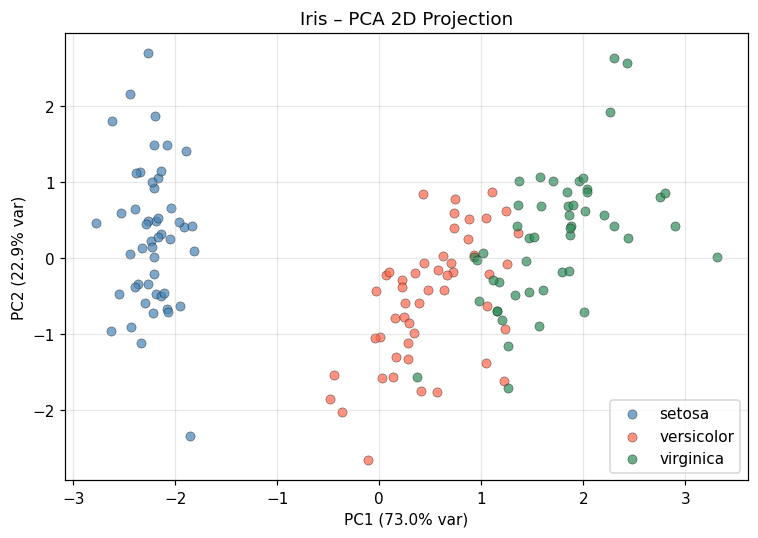

In [ ]:
scaler_pca = StandardScaler()
X_sc_all = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc_all)

print(f"Explained variance ratio : {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance explained : {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 5))
for cls, (color, label) in enumerate(zip(['steelblue','tomato','seagreen'], iris.target_names)):
    ax.scatter(X_pca[y==cls, 0], X_pca[y==cls, 1],
               color=color, label=label, alpha=0.7, edgecolors='k', linewidths=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Iris – PCA 2D Projection"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Hyperparameter Tuning with GridSearchCV
Hyperparameters (like SVM's `C` and `gamma`) are not learned from data — they must be set by the user.  
`GridSearchCV` exhaustively tries combinations and picks the best via cross-validation.


In [ ]:
pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=42))])
param_grid = {
    'svm__C':      [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 'auto'],
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")


Best parameters : {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV accuracy: 0.9733


## 10. Final Evaluation & Summary
Evaluate the best tuned model on the held-out test set.


Best tuned SVM – Test Accuracy: 0.9667  (96.7%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



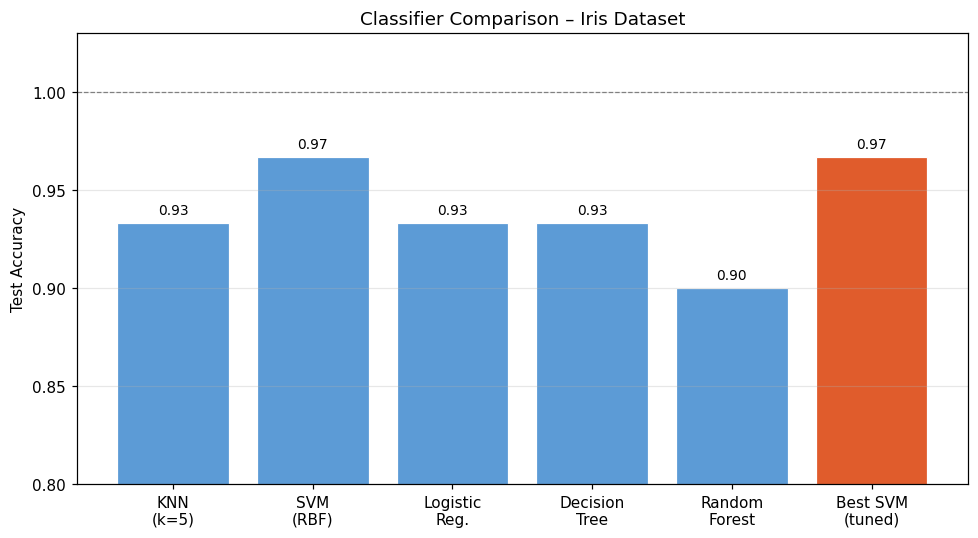

In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)     # Pipeline contains scaler, no need to pre-scale
y_pred_best = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred_best)

print(f"Best tuned SVM – Test Accuracy: {final_acc:.4f}  ({final_acc*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

# ── Final comparison bar chart ──
models = ['KNN\n(k=5)', 'SVM\n(RBF)', 'Logistic\nReg.', 'Decision\nTree', 'Random\nForest', 'Best SVM\n(tuned)']
accs   = [0.9333, 0.9667, 0.9333, 0.9333, 0.9000, final_acc]
bar_colors = ['#5c9bd6']*5 + ['#e05c2c']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, accs, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0.8, 1.03); ax.set_ylabel("Test Accuracy")
ax.set_title("Classifier Comparison – Iris Dataset")
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## ✅ Assignment Complete!

### Key Takeaways

| Concept | What we did |
|---|---|
| **Data exploration** | Shapes, class distribution, feature histograms, scatter plots |
| **Train/Test split** | 80/20 stratified split to avoid data leakage |
| **Feature scaling** | `StandardScaler` fit on train only |
| **KNN** | Classified by majority vote of k neighbours; best k=1 (96.7%) |
| **Multiple classifiers** | KNN, SVM, Logistic Regression, Decision Tree, Random Forest |
| **Cross-validation** | 5-fold CV for reliable performance estimates |
| **Learning curves** | Diagnose overfitting vs underfitting |
| **PCA** | Reduced 4D → 2D; 95.8% variance retained |
| **GridSearchCV** | Tuned SVM hyperparameters (C=10, kernel=rbf) → **97.3% CV accuracy** |

### Best model: SVM with RBF kernel, C=10 — Test accuracy **96.7%** 🎉
